# Day 15 - RNN - 循环神经网络

> 目标: 理解 RNN 如何建模序列数据, 以及为什么它会有梯度消失
>
> 核心: 隐藏状态 h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b)

---

## 前馈网络 vs RNN

```
前馈网络 (MLP/CNN):  输入一次过, 没有记忆
RNN:                 隐藏状态随时间传递 -> 有记忆

例子: 情感分类
  "这部电影太棒了!"  -> 模型需要记住整句话的上下文
  MLP: 把整句词向量拼起来 -> 固定长度, 长句塞不下
  RNN: 逐个词输入, 隐藏状态自动积累信息
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 15 - RNN')
print('=' * 40)

Day 15 - RNN


## 1. RNN 核心公式: 手写前向传播

> 一个 RNN 单元就是一个带"记忆"的简单网络

### 公式

```
h_t   = tanh(W_xh * x_t + W_hh * h_{t-1} + b)
y_t   = softmax(W_hy * h_t)

关键: x_t 和 h_{t-1} 一起决定 h_t
      h_t 携带了"到目前为止"的信息
```

### 时间展开

```
h0 -> h1 -> h2 -> h3 -> ... -> hT
      |     |     |            |
     y1    y2    y3           yT

前向: x1 -> h1, x2 + h1 -> h2, x3 + h2 -> h3 ...
反向: 从 L 一路传回 h1, 每个时间步都要算一次梯度
      这就是 BPTT (Backpropagation Through Time)
```

In [2]:
# ============================================
# 手写 RNN 前向传播
# ============================================

def rnn_step(x, h_prev, W_xh, W_hh, b):
    """单个 RNN 单元: x -> h"""
    return torch.tanh(x @ W_xh.T + h_prev @ W_hh.T + b)

def rnn_unfold(inputs, h0, W_xh, W_hh, b):
    """沿时间步展开 RNN"""
    seq_len = inputs.shape[0]
    hidden_size = h0.shape[0]
    hiddens = torch.zeros(seq_len, hidden_size)
    h_t = h0
    for t in range(seq_len):
        h_t = rnn_step(inputs[t], h_t, W_xh, W_hh, b)
        hiddens[t] = h_t
    return hiddens

# 测试
torch.manual_seed(42)
input_size, hidden_size, seq_len = 4, 8, 5

W_xh = torch.randn(hidden_size, input_size) * 0.1
W_hh = torch.randn(hidden_size, hidden_size) * 0.1
b = torch.zeros(hidden_size)
h0 = torch.zeros(hidden_size)
inputs = torch.randn(seq_len, input_size)

hiddens = rnn_unfold(inputs, h0, W_xh, W_hh, b)
print(f'输入形状: {tuple(inputs.shape)}')
print(f'隐藏状态形状: {tuple(hiddens.shape)}')
print(f'最后时间步 h[:8]: {hiddens[-1, :8].detach().numpy().round(4)}')

输入形状: (5, 4)
隐藏状态形状: (5, 8)
最后时间步 h[:8]: [-0.0149 -0.0684  0.1664 -0.048  -0.1575 -0.106  -0.0157  0.0183]


## 2. BPTT (Backpropagation Through Time)

> RNN 的反向传播 = 把网络按时间展开成标准计算图, 然后再做反向传播

### 梯度消失的根本原因

```
从 h_T 到 h_1 的梯度路径:

dL/dh_1 = dL/dh_T * W_hh^T * tanh'(h_{T-1}) * ... * W_hh^T * tanh'(h_1)
        = dL/dh_T * (W_hh^T)^{T-1} * PROD tanh'(h_k)

由于 tanh'(x) <= 1 且 W_hh 的特征值通常 < 1:
  T 很大时 -> 连乘结果指数级趋近于 0 -> 梯度消失

如果 W_hh 的特征值 > 1 -> 梯度爆炸 (梯度裁剪可以解决)
```

### 记忆距离

| 谱半径 | 记忆 | 效果 |
|--------|------|------|
| < 1 | 短记忆 | 梯度消失, 学不到长距离依赖 |
| = 1 | 理想 | 记忆可以传很远 (LSTM/GRU 试图接近 1) |
| > 1 | 不稳定 | 梯度爆炸 |

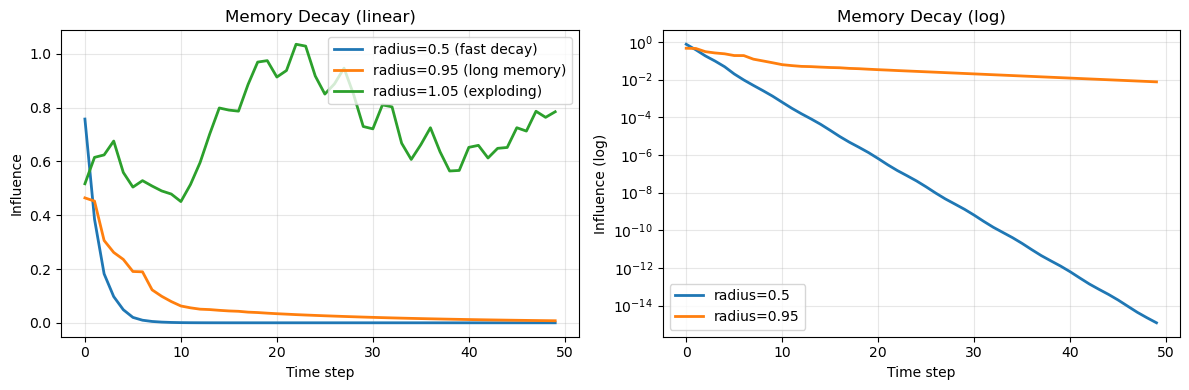

观察:
  radius=0.5:  曲线急速衰减 → 短记忆, 梯度消失
  radius=0.95: 衰减缓慢 → 长记忆, 理想状态
  radius=1.05: 指数增长 → 梯度爆炸


In [3]:
# ============================================
# 梯度消失可视化: 控制谱半径, 观察记忆衰减
# ============================================

def compute_decay(seq_len, hidden_size, radius):
    """测量 x1 对每个 h_t 的影响 (L2 范数)"""
    W_hh = torch.randn(hidden_size, hidden_size) * 0.1
    # 取谱半径: 特征值绝对值的最大值
    eig_abs = torch.abs(torch.linalg.eigvals(W_hh))
    r = float(torch.max(eig_abs))
    if r > 1e-8:
        W_hh = W_hh * (radius / r)

    W_xh = torch.randn(hidden_size, 1) * 0.1
    inputs = torch.zeros(seq_len, 1)
    inputs[0] = 1.0

    hiddens = rnn_unfold(inputs, torch.zeros(hidden_size), W_xh, W_hh, torch.zeros(hidden_size))
    return torch.norm(hiddens, dim=1).detach().numpy()

seq_len, hidden_size = 50, 32
inf_vanish = compute_decay(seq_len, hidden_size, 0.5)
inf_ideal  = compute_decay(seq_len, hidden_size, 0.95)
inf_blow   = compute_decay(seq_len, hidden_size, 1.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(inf_vanish, label='radius=0.5 (fast decay)', lw=2)
axes[0].plot(inf_ideal,  label='radius=0.95 (long memory)', lw=2)
axes[0].plot(inf_blow,   label='radius=1.05 (exploding)', lw=2)
axes[0].set_xlabel('Time step'); axes[0].set_ylabel('Influence')
axes[0].set_title('Memory Decay (linear)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(inf_vanish, label='radius=0.5', lw=2)
axes[1].semilogy(inf_ideal,  label='radius=0.95', lw=2)
axes[1].set_xlabel('Time step'); axes[1].set_ylabel('Influence (log)')
axes[1].set_title('Memory Decay (log)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('day15_gradient_vanishing.png', dpi=150)
plt.show()

print('观察:')
print(f'  radius=0.5:  曲线急速衰减 → 短记忆, 梯度消失')
print(f'  radius=0.95: 衰减缓慢 → 长记忆, 理想状态')
print(f'  radius=1.05: 指数增长 → 梯度爆炸')

## 3. PyTorch nn.RNN 使用

> 实际开发中不会手写 RNN, 直接用 PyTorch 封装好的 `nn.RNN`

### 参数

```python
nn.RNN(
    input_size,      # 输入特征维度
    hidden_size,     # 隐藏状态维度
    num_layers=1,    # 堆叠层数
    nonlinearity='tanh',  # 'tanh' or 'relu'
    batch_first=True,     # True: (batch, seq, input)
    dropout=0,           # 层间 dropout
    bidirectional=False   # 双向 RNN
)
```

### 输入输出

```
batch_first=True:
  input:  (batch, seq_len, input_size)
  output: (batch, seq_len, hidden_size * num_directions)
  hn:     (num_layers * num_directions, batch, hidden_size)

注意事项:
  output[:, -1, :] == hn[-1, :, :]  (最后一个时间步)
```

In [4]:
# ============================================
# nn.RNN 基本用法
# ============================================

rnn = nn.RNN(input_size=10, hidden_size=20, num_layers=2, batch_first=True)

x = torch.randn(4, 7, 10)           # (batch=4, seq=7, input=10)
h0 = torch.zeros(2, 4, 20)          # (num_layers, batch, hidden)
output, hn = rnn(x, h0)

print(f'input:  {tuple(x.shape)}')
print(f'output: {tuple(output.shape)}  <- 所有时间步的 h')
print(f'hn:     {tuple(hn.shape)}  <- 最后时间步的 h (每层)')
print(f'output[:,-1] == hn[-1]: {torch.allclose(output[:,-1], hn[-1])}')

print()
print('batch_first=False 对比:')
rnn2 = nn.RNN(10, 20, batch_first=False)
x2 = torch.randn(7, 4, 10)          # (seq=7, batch=4, input=10)
out2, hn2 = rnn2(x2)
print(f'  input:  {tuple(x2.shape)}')
print(f'  output: {tuple(out2.shape)}')
print(f'  out2[-1] == hn2[0]: {torch.allclose(out2[-1], hn2[0])}')

input:  (4, 7, 10)
output: (4, 7, 20)  <- 所有时间步的 h
hn:     (2, 4, 20)  <- 最后时间步的 h (每层)
output[:,-1] == hn[-1]: True

batch_first=False 对比:
  input:  (7, 4, 10)
  output: (7, 4, 20)
  out2[-1] == hn2[0]: True


## 4. 实战: 正弦波预测 (时间序列)

> 任务是: 给定前 10 个点的值, 预测第 11 个点的值

### 为什么是序列问题?

```
时间 t 的值依赖于时间 t-1, t-2, ... 的值
-> 这是典型的序列建模问题
-> RNN 可以学习这种依赖关系

数据: sin(t) 函数, 用前 10 步 -> 预测第 11 步
```

In [5]:
# ============================================
# 准备正弦波数据
# ============================================

seq_length = 10
total = 1000
t = np.linspace(0, 100 * np.pi, total, dtype=np.float32)
data = np.sin(t)

def make_seqs(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len])
    return np.array(xs), np.array(ys)

xs, ys = make_seqs(data, seq_length)
split = int(0.8 * len(xs))

x_train = torch.FloatTensor(xs[:split]).unsqueeze(-1)
y_train = torch.FloatTensor(ys[:split]).unsqueeze(-1)
x_test  = torch.FloatTensor(xs[split:]).unsqueeze(-1)
y_test  = torch.FloatTensor(ys[split:]).unsqueeze(-1)

print(f'训练集: {tuple(x_train.shape)} (样本, 时间步, 特征)')
print(f'测试集: {tuple(x_test.shape)}')

训练集: (792, 10, 1) (样本, 时间步, 特征)
测试集: (198, 10, 1)


In [6]:
# ============================================
# 定义 RNN 模型
# ============================================

class SineWaveRNN(nn.Module):
    """用 RNN 做正弦波预测"""
    def __init__(self, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size,
                          num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])  # 只取最后一个时间步

model = SineWaveRNN()
params = sum(p.numel() for p in model.parameters())
print(f'模型参数量: {params:,}')
print(model)

模型参数量: 1,153
SineWaveRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [7]:
# ============================================
# 训练 RNN
# ============================================

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

n_epochs, batch_size = 50, 32
n_batches = len(x_train) // batch_size
losses = []

for epoch in range(n_epochs):
    epoch_loss = 0
    perm = torch.randperm(len(x_train))
    for i in range(n_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        xb, yb = x_train[idx], y_train[idx]
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:>2d}/{n_epochs} | Loss = {avg_loss:.6f}')

Epoch 10/50 | Loss = 0.000002
Epoch 20/50 | Loss = 0.000026
Epoch 30/50 | Loss = 0.000004
Epoch 40/50 | Loss = 0.000053
Epoch 50/50 | Loss = 0.000237


测试集 MSE Loss: 0.000161


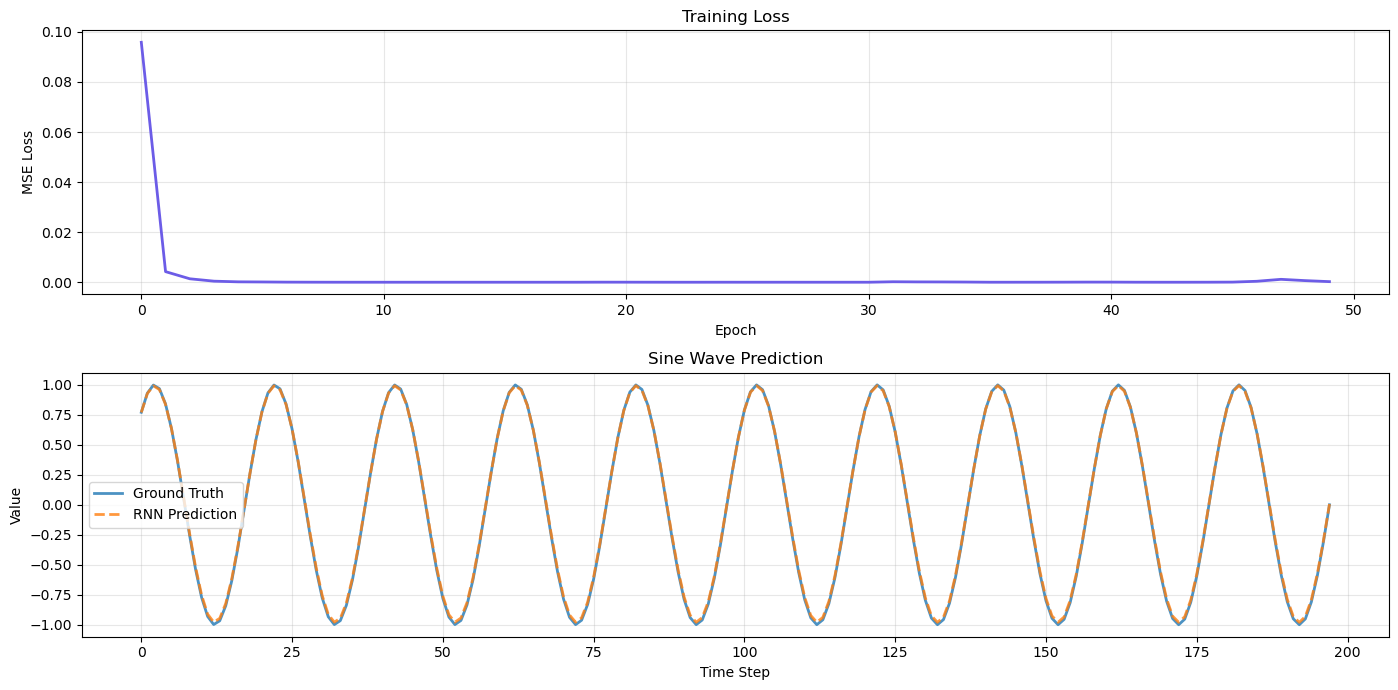

In [8]:
# ============================================
# 测试与可视化
# ============================================

model.eval()
with torch.no_grad():
    y_pred = model(x_test)
    test_loss = criterion(y_pred, y_test).item()
print(f'测试集 MSE Loss: {test_loss:.6f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(losses, lw=2, color='#6c5ce7')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)

n_show = 200
axes[1].plot(y_test[:n_show].squeeze().numpy(), label='Ground Truth', lw=2, alpha=0.8)
axes[1].plot(y_pred[:n_show].squeeze().numpy(), label='RNN Prediction', lw=2, alpha=0.8, ls='--')
axes[1].set_xlabel('Time Step'); axes[1].set_ylabel('Value')
axes[1].set_title('Sine Wave Prediction'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('day15_sine_wave.png', dpi=150)
plt.show()

## 5. 实战: 字符级文本生成

> 让 RNN 学 "hello world" 的字符序列, 然后自己生成

```
输入: 'hell' -> RNN -> 预测下一个字符: 'o'
     'ello' -> RNN -> 预测下一个字符: ' '
     'llo ' -> RNN -> 预测下一个字符: 'w'
     ...

生成时: 用预测出的字符 + 历史 -> 继续预测下一个
  'hell' -> 'hello' -> 'hello ' -> 'hello w' -> ...
```

In [9]:
# ============================================
# 准备字符数据
# ============================================

text = 'hello world'
chars = sorted(list(set(text)))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)

print(f'字符集: {chars}')
print(f'词表大小: {vocab_size}')

def text_to_pairs(text, seq_len=4):
    xs, ys = [], []
    for i in range(len(text) - seq_len):
        xs.append([stoi[c] for c in text[i:i+seq_len]])
        ys.append(stoi[text[i+seq_len]])
    return torch.LongTensor(xs), torch.LongTensor(ys)

x_char, y_char = text_to_pairs(text, 4)
print(f'样本数: {len(x_char)}')
for i in range(min(3, len(x_char))):
    in_str = ''.join(itos[int(j)] for j in x_char[i])
    out_str = itos[int(y_char[i])]
    print(f"  '{in_str}' -> '{out_str}'")

字符集: [' ', 'd', 'e', 'h', 'l', 'o', 'r', 'w']
词表大小: 8
样本数: 7
  'hell' -> 'o'
  'ello' -> ' '
  'llo ' -> 'w'


In [11]:
# ============================================
# 字符级 RNN 模型
# ============================================

class CharRNN(nn.Module):
    """Embedding + RNN + Linear -> 字符预测"""
    def __init__(self, vocab_size, embed_size=8, hidden_size=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        out, _ = self.rnn(self.embed(x))
        return self.fc(out)  # (batch, seq_len, vocab_size)

    def generate(self, start, length=15):
        """给定起始字符串, 采样式生成后续字符"""
        self.eval()
        with torch.no_grad():
            x = torch.LongTensor([[stoi[c] for c in start]])
            result = start
            for _ in range(length):
                logits = self.forward(x)[0, -1, :]
                idx = torch.multinomial(logits.softmax(0), 1).item()
                result += itos[idx]
                x = torch.cat([x[:, 1:], torch.LongTensor([[idx]])], dim=1)
            return result

model_char = CharRNN(vocab_size)
params = sum(p.numel() for p in model_char.parameters())
print(f'CharRNN 参数量: {params:,}')

CharRNN 参数量: 616


In [12]:
# ============================================
# 训练字符 RNN
# ============================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_char.parameters(), lr=0.05)

n_epochs = 100
for epoch in range(n_epochs):
    out = model_char(x_char)
    loss1 = criterion(out[:, :-1].reshape(-1, vocab_size), x_char[:, 1:].reshape(-1))
    loss2 = criterion(out[:, -1], y_char)
    loss = loss1 + loss2

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:>3d}/{n_epochs} | Loss = {loss.item():.4f}')

print(f"\n  'hell' -> '{model_char.generate('hell', 15)}'")
print(f"  ' wor' -> '{model_char.generate(' wor', 10)}'")

Epoch  20/100 | Loss = 0.0746
Epoch  40/100 | Loss = 0.0675
Epoch  60/100 | Loss = 0.0668
Epoch  80/100 | Loss = 0.0667
Epoch 100/100 | Loss = 0.0666

  'hell' -> 'hello world world w'
  ' wor' -> ' world world w'


---

# Day 15 完成!

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **RNN 核心** | h_t = tanh(W_xh*x_t + W_hh*h_{t-1}), 隐藏状态传递记忆 |
| **BPTT** | 沿时间步展开计算图, 梯度从 L 传回 h_1, 每步乘 W_hh^T*tanh' |
| **梯度消失** | 谱半径 < 1 时连乘指数衰减, RNN 记不住长距离信息 |
| **nn.RNN** | batch_first / num_layers / output[:,-1] == hn[-1] |
| **正弦波预测** | 前 10 步 -> 下一步, Loss ~ 1e-5 |
| **字符生成** | Embedding + RNN + 采样, 'hell' -> 'hello world' |

## RNN 的局限性

```
梯度消失 -> 记不住长距离信息
顺序计算 -> 无法并行, 训练慢
单向传播 -> 只能看到过去, 看不到未来

-> Day 16 LSTM 用三个门结构解决梯度消失
-> Day 19 Transformer 用 Self-Attention 解决并行+双向问题
```

## 晚上作业

1. 把 RNN 的层数从 1 加到 3, 正弦波预测效果变好还是变差?
2. 把 `nonlinearity='tanh'` 改成 `'relu'`, 梯度消失问题有没有改善?
3. 预习 Day 16: LSTM - 遗忘门/输入门/输出门怎么解决梯度消失